# Data Loader

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys
import pandas as pd
import re
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


pd.set_option('display.max_colwidth', None)

ROOT = Path.cwd()
while not (ROOT / ".git").exists():
    ROOT = ROOT.parent

DATA = ROOT / "data" / "prb_articles_labeled_Jan2016-Jun2026_duplicate-free.json"
DATA_SAMPLE = ROOT / "data" / "prb_articles_labeled_Jan2016-Jun2026_duplicate-free_sample.json"

#CLEANED_DATA is output of prep_data() from preprocessing.py
CLEANED_DATA  = ROOT / "data" / "cleaned_data.json"

MAPPER_MODULE_PATH = str(ROOT / "src" / "data")
PHYSH_URL_PREFIX = "https://doi.org/10.29172/"

#For importing functions from preprocessing.py
if MAPPER_MODULE_PATH not in sys.path:
    sys.path.append(MAPPER_MODULE_PATH)

data_to_load = DATA if DATA.exists() else DATA_SAMPLE
df = pd.read_json(data_to_load)

print(f"Loaded data from {data_to_load.name}")
df.info()

Loaded data from prb_articles_labeled_Jan2016-Jun2026_duplicate-free.json
<class 'pandas.DataFrame'>
RangeIndex: 50838 entries, 0 to 50837
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   doi          50838 non-null  str           
 1   title        50838 non-null  str           
 2   abstract     50838 non-null  str           
 3   physh        50838 non-null  object        
 4   date         50838 non-null  datetime64[us]
 5   articleType  50838 non-null  str           
dtypes: datetime64[us](1), object(1), str(4)
memory usage: 2.3+ MB


# Mapping PhySH tag concept IDs to corresponding names

In [3]:
from preprocessing import concept_hierarchy_graph

graph_hierarchy = concept_hierarchy_graph()
label_naming = nx.get_node_attributes(graph_hierarchy,'label')
labeled_hierarchy = nx.relabel_nodes(graph_hierarchy, label_naming, copy=True)

In [4]:
#Applying it to the concept IDs in the dataset and mapping it to PhySH tag names.
df["physh_names"]=df["physh"].apply(
    lambda uuid_list: [
        label_naming.get(PHYSH_URL_PREFIX+uuid,None) for uuid in uuid_list
    ]
)
df.head()

doi  \
0  10.1103/w3nv-g337   
1  10.1103/gggh-jy6j   
2  10.1103/ssdc-9bsk   
3  10.1103/xz4g-jlbg   
4  10.1103/66qc-hrzr   

                                                                                                                                                                                                                                                                                                                                                                                                                                                             title  \
0  Interface-driven mechanisms for enhancing magnetocrystalline anisotropy and Dzyaloshinskii-Moriya interaction in <math xmlns="http://www.w3.org/1998/Math/MathML"><mrow><mi>M</mi><mi mathvariant="normal">T</mi><msub><mi mathvariant="normal">e</mi><mn>2</mn></msub><mo>/</mo><mi>Cr</mi><msub><mi mathvariant="normal">I</mi><mn>3</mn></msub></mrow></math> (<math xmlns="http://www.w3.org/1998/Math/MathML"><mi>M</mi></math> = Pd, Pt) heterostructures   
1                                                                                                                                                                                                                                                                                                                                                                               Frequency-controlled critical non-Hermitian skin effect in a topolectrical circuit   
2                                                                                                                                                                                                                                                                                                                                                                            Finite-temperature fermion Monte Carlo simulations of frustrated spin-Peierls systems   
3                                                                                                                                                                                                                                                                                Breakdown of boundary criticality and exotic topological semimetals in <math xmlns="http://www.w3.org/1998/Math/MathML"><mi mathvariant="script">PT</mi></math>-invariant systems   
4                                                                                                                                                                                                                                                                                             Double exceptional points in <math xmlns="http://www.w3.org/1998/Math/MathML"><mi mathvariant="script">PT</mi></math>-symmetric structures with an anisotropic layer   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

# Statistics on the full dataset

In [5]:
#Text statistics
print(f"{df["abstract"].str.contains("xmlns").sum()/df["abstract"].shape[0]*100:.2f}% of abstracts contain MathXML.")
print(f"{df["title"].str.contains("xmlns").sum()/df["title"].shape[0]*100:.2f}% of titles contain MathXML.")


66.35% of abstracts contain MathXML.
29.71% of titles contain MathXML.


In [6]:
#Load cleaned up dataframe for statistics
df_cleaned = pd.read_json(CLEANED_DATA)


## Text Statistics

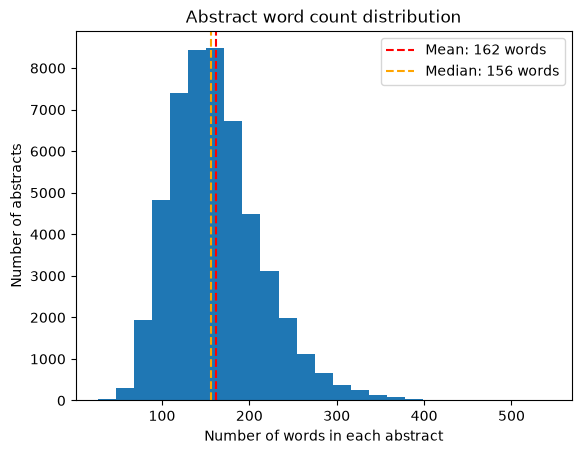

In [7]:
stats_abstract = df_cleaned["abstract"].str.split().str.len()

plt.hist(stats_abstract,bins=25)
plt.xlabel('Number of words in each abstract')
plt.ylabel('Number of abstracts')
plt.title('Abstract word count distribution')
plt.axvline(stats_abstract.mean(),color='red',linestyle='--',label=f'Mean: {stats_abstract.mean():.0f} words')
plt.axvline(stats_abstract.median(), color='orange', linestyle='--', label=f'Median: {stats_abstract.median():.0f} words')
plt.legend();


In [8]:
print(stats_abstract.describe().round(2))

count    50398.00
mean       162.40
std         52.02
min         27.00
25%        126.00
50%        156.00
75%        191.00
max        543.00
Name: abstract, dtype: float64


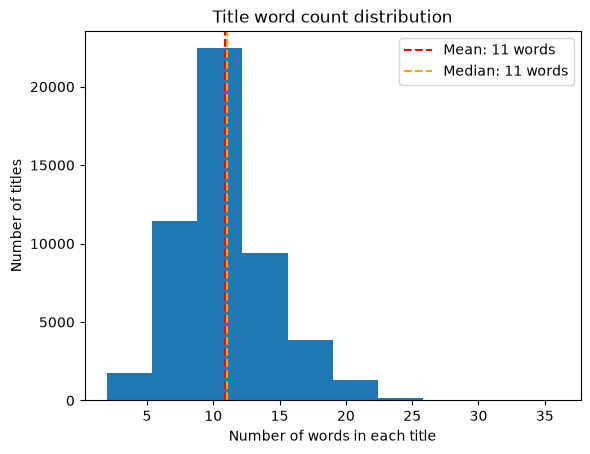

In [9]:
stats_title = df_cleaned["title"].str.split().str.len()

plt.hist(stats_title,bins=10)
plt.xlabel('Number of words in each title')
plt.ylabel('Number of titles')
plt.title('Title word count distribution')
plt.axvline(stats_title.mean(),color='red',linestyle='--',label=f'Mean: {stats_title.mean():.0f} words')
plt.axvline(stats_title.median(), color='orange', linestyle='--', label=f'Median: {stats_title.median():.0f} words')
plt.legend();


In [10]:
print(stats_title.describe().round(2))

count    50398.00
mean        10.91
std          3.55
min          2.00
25%          8.00
50%         11.00
75%         13.00
max         36.00
Name: title, dtype: float64


## PhySH tags Statistics

In [11]:
print(f"Number of unique tags: {df_cleaned['physh'].explode().nunique()}")

print(f"Entries with missing physh tags: {df[(df['physh'].apply(lambda x : len(x)))==0].shape[0]}")



Number of unique tags: 2421
Entries with missing physh tags: 440


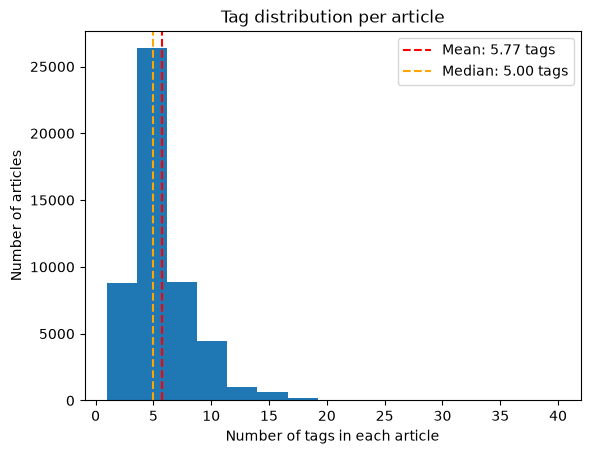

In [12]:
stats_tags = df_cleaned['physh_names'].str.len()

plt.hist(stats_tags,bins=15)
plt.xlabel('Number of tags in each article')
plt.ylabel('Number of articles')
plt.title('Tag distribution per article')
plt.axvline(stats_tags.mean(),color='red',linestyle='--',label=f'Mean: {stats_tags.mean():.2f} tags')
plt.axvline(stats_tags.median(), color='orange', linestyle='--', label=f'Median: {stats_tags.median():.2f} tags')
plt.legend();

In [13]:
stats_tags.describe().round(2)

count    50398.00
mean         5.77
std          2.75
min          1.00
25%          4.00
50%          5.00
75%          7.00
max         40.00
Name: physh_names, dtype: float64

In [14]:
print(f"There are {df_cleaned[stats_tags >20].shape[0]} papers with over 20 tags.")
print(f"There are {df_cleaned[stats_tags ==1].shape[0]} papers with only 1 tag.")

There are 91 papers with over 20 tags.
There are 393 papers with only 1 tag.


In [15]:
# That one paper with 40 tags!!
df_cleaned[stats_tags == 40]    

,doi,title,abstract,physh,date,articleType,physh_names
20040,10.1103/PhysRevB.100.174502,Zero Cu valence and superconductivity in high-quality CuxBi2Se3 crystal,"In this work, the role of Cu dopants in the development of superconductivity in Bi2Se3 is investigated. A series of CuxBi2Se3 (x=0–0.3) crystals is grown using the Bridgman method and electrochemical techniques. Based on the observable lattice increases along the c axis, the existence of Cu atoms intercalated in the van der Waals (vdW) gaps in Bi2Se3 is verified by x-ray diffraction, scanning electron microsopy–energy dispersive spectroscopy, and transmission electron microscopy analysis. Furthermore, the chemical state of the Cu is found to be zero valence by characterization of the x-ray photoelectron and Auger electron spectra. The absence of Cu1+ and Cu2+ in the electron energy-loss spectroscopy near-edge fine structure is confirmed as well. Meanwhile, our Raman data also show the same result: the intercalation of Cu in the vdW gap which weakens the binding of the quintuple layers in the Cu0.1Bi2Se3 crystal. The electric resistance and magnetic susceptibility show a superconducting transition near 3–3.4 K in the series of Cu-doped Bi2Se3. A sharp superconducting transition with the highest value of TC=3.4K and the largest magnetic shielding fraction of 84% is observed in the optimized 10% Cu-doped Bi2Se3. These results imply that the formation of superconducting quasiparticles is not related to the charge transfer of Cu, but is supported by the internal stress of Cu intercalated in the van der Waals gap. The superconducting transition observed in the specific heat implies that the superconductivity in CuxBi2Se3 is unconventional.","[d9af0237-9064-4875-aa7e-1293ffa03f4e, 528c8088-7367-43ee-8987-bcb487dd8209, 32de7669-68ef-4f3e-9598-2a70300ea01e, 18d10b28-37f1-434d-a95b-19cf71fc6f05, 0e1491f9-ac6a-4d41-81e1-86d8a51dfa32, 675773f0-6ff3-44de-8600-2e9034eea9f0, 816fad41-e621-48cc-b377-1e2c65b63074, 64f26e6b-2baf-45fa-bd50-974c3139e6bc, c2ea95f8-c209-44d7-b8f7-a6baf632c46a, 4d734e8f-2c3b-42a0-a4cb-8f453aeae99d, 78855062-19be-4a72-9393-4e848f839e5f, 9af7b654-70b3-4add-ad23-619d3b98ba5a, 843259d3-c0d8-4f11-a577-8cf874f3a636, 278b9d25-e618-4a6f-abe5-bc10e5c41dc2, c4ed35b0-1090-409c-9667-85f9ac03e9c0, 6e829c75-cad5-47b7-82f0-0aa11e506090, c21c30b0-2219-4793-9841-d9e9d3d0dd2c, 0003fc3f-1522-4fca-bf3f-bcef0dcec405, 8156d7cb-6ab9-4097-be2b-4aa71aad93a3, 8c2c45c3-8b11-425e-b5d8-9faec4b6dcfd, cb96f9d7-13ba-485d-ba02-07da9077c686, 34773509-53cc-4885-a027-7bd3497f7157, ee6a7985-5dde-4bf8-9b7b-859f03f7c524, 8d9a5500-7204-4ae4-8a93-388da8f8d432, bf7626bc-fac0-45d3-ac13-aa181bacba5b, b6850136-0dff-41c9-85da-b6bcf1518811, 22b17e02-28a0-4b88-ae3b-2520aa22cfb9, 68bb3b4f-c58b-4efb-8500-325b23986472, 68cf8652-f610-49f1-91be-0b5229c168ba, c9fb88dd-03ca-453d-b78c-5b9bb956df7f, 7d961f4e-e5a1-4405-826f-e054c0e90dff, 70da3cfc-db10-4e3f-8d94-2646155ceaf5, 2250b5f3-dfa1-4ca7-bedf-fff5d41bd6ea, 6a71ea1b-05e8-49de-92a8-87e5306cc3e3, bfe403ee-cd34-466b-b8bf-f90b4d4431fc, 68cf8652-f610-49f1-91be-0b5229c168ba, de7c563b-63ee-4b54-b76c-be410edf4051, 65266af4-488c-4bbf-a84a-36626bc9aac8, ca8ddaad-441c-481c-93b3-65f46125fb93, 4fcc035e-7eb4-46f6-b347-5cc975e5ed95]",2019-11-04,article,"[X-ray photoelectron spectroscopy, X-ray powder diffraction, X-ray diffraction, X-ray techniques, Resistivity measurements, Transport techniques, Specific heat measurements, Calorimetry, Thermal techniques, Scanning electron microscopy, Crystallization, Chemical synthesis, Crystal growth, Annealing, Sample preparation, DC susceptibility measurements, Susceptibility measurements, Magnetic techniques, Infrared techniques, Raman spectroscopy, Energy loss near-edge fine structure, Electron microscopy, High-resolution transmission electron microscopy, Electron energy loss spectroscopy, Auger electron spectroscopy, Electron techniques, Cryogenics, Liquid helium cooling, Topological superconductors, Topological insulators, Unconven

In [16]:
df_label_counts = df['physh_names'].explode().value_counts().to_frame(name='counts')
df_label_counts.sort_values(by='counts', ascending=True)

,counts
physh_names,
Welding,1
Helicity,1
Twisted multilayer graphene,1
Doppler ultrasonography,1
Capacitance measurements,1
...,...
Magnetism,3646
Topological materials,3677
Density functional theory,3852


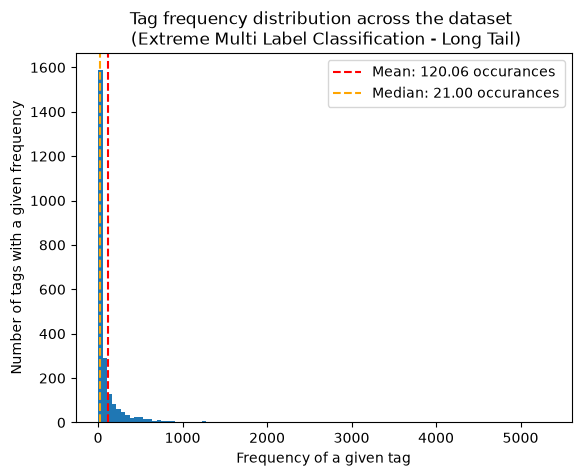

In [42]:
plt.hist(df_label_counts['counts'],bins=100);

plt.xlabel('Frequency of a given tag')
plt.ylabel('Number of tags with a given frequency')
plt.title('Tag frequency distribution across the dataset \n (Extreme Multi Label Classification - Long Tail)')
plt.axvline(df_label_counts['counts'].mean(),color='red',linestyle='--',label=f'Mean: {df_label_counts['counts'].mean():.2f} occurances')
plt.axvline(df_label_counts['counts'].median(), color='orange', linestyle='--', label=f'Median: {df_label_counts['counts'].median():.2f} occurances')
plt.legend();

In [22]:
df_label_counts['counts'].describe().round(2)

count    2421.00
mean      120.06
std       323.56
min         1.00
25%         4.00
50%        21.00
75%        94.00
max      5338.00
Name: counts, dtype: float64

In [29]:
#10 most popular tags
df_label_counts['counts'].head(10)

physh_names
Electronic structure             5338
First-principles calculations    4444
Density functional theory        3852
Topological materials            3677
Magnetism                        3646
Superconductivity                3541
Strongly correlated systems      2908
Spin-orbit coupling              2817
2-dimensional systems            2554
Topological phases of matter     2331
Name: counts, dtype: int64

In [36]:
print(f"Number of tags with occurance less than 50 times: {len(list(df_label_counts[df_label_counts['counts']<51].index))}")

#This was checking if there are any tags which are low ocurring and don't appear in the graph.
print([doi for doi in list(df_label_counts[df_label_counts['counts']<50].index) if not labeled_hierarchy.has_node(doi)])

#Checking for any tags that didn't get labeled
print([x for x in nx.get_node_attributes(graph_hierarchy,'label').values() if x == ''])

Number of tags with occurance less than 50 times: 1556
[]
[]


In [37]:
#Deprecated tag names
[nx.get_node_attributes(graph_hierarchy,'label')[doi] for doi in list(nx.get_node_attributes(graph_hierarchy,'deprecated').keys())]

['Axis specification',
 'General Physics',
 'Electromagnetism',
 'Subcellular processes & properties',
 'Pathology',
 'Classical field theory',
 'Diseases',
 'Charge distributions',
 'Biological optics']

# NetworkX graph hierarchy of tags

## PhySH REST API

In [44]:
import requests

concepts_url = "https://app.swaggerhub.com/proxy/https://physh.org/concepts"
facets_url = "https://app.swaggerhub.com/proxy/https://physh.org/facets"
discipline_url = "https://app.swaggerhub.com/proxy/https://physh.org/disciplines"

headers = {"Accept": "application/json"}

concepts_response = requests.get(concepts_url, headers=headers)
facets_response = requests.get(facets_url, headers=headers)
discipline_response = requests.get(discipline_url, headers=headers)

print("---FACETS---")
for items in facets_response.json():
    print(items.get("uri"),items.get("label"))
print("---DISCIPLINES---")
for items in discipline_response.json():
    print(items.get("uri"),items.get("label"))


---FACETS---
https://doi.org/10.29172/bdb1ef91-b776-4e36-8f8f-3e93666bac1e Research Areas
https://doi.org/10.29172/f45b3c40-959c-4e90-ba0e-38232980802a Physical Systems
https://doi.org/10.29172/42d3b740-7576-46a7-8b8f-331568a778b1 Properties
https://doi.org/10.29172/fa2a6718-de5c-4c05-bf00-f169a55234d5 Techniques
https://doi.org/10.29172/f9b1361d-01a4-4d29-b6a5-69b0b9bf071e Professional Topics
---DISCIPLINES---
https://doi.org/10.29172/7b910510-8488-42c8-ac66-4a0afdc726c9 APS Taxonomy
https://doi.org/10.29172/c3ec1cb0-fc2e-4669-a886-a82178c6ceda Accelerators & Beams
https://doi.org/10.29172/8ab3d2b7-b50b-460e-b086-8990cfcbd350 Atomic, Molecular & Optical
https://doi.org/10.29172/a48f173e-6459-4642-a711-a6e731807625 Condensed Matter, Materials & Applied Physics
https://doi.org/10.29172/e6f3f236-70e5-473b-bcca-82da13857537 Energy Science & Technology
https://doi.org/10.29172/512fd433-7b6d-4535-bb60-78f3bf431bc3 Fluid Dynamics
https://doi.org/10.29172/0f4313da-ec73-46f5-b24f-521a1fcb6db7 

In [45]:
print(f"Number of facets: {len(facets_response.json())}")
print(f"Number of disciplines: {len(discipline_response.json())}")
#print(f"Number of concepts: {len(concepts_response.json())}")

Number of facets: 5
Number of disciplines: 18


In [47]:
from preprocessing import load_physh_graph,SKOS

g = load_physh_graph()

#Counting the various kinds of predicates appearing in the RDF file
predicate_counts = {}

for child,predicate, parent in g:
    # use qname() to format URIs into readable XML tags like 'skos:broader'
    try:
        tag_name = rdf_data.namespace_manager.qname(predicate)
    except Exception:
        tag_name = str(predicate) # Fallback to raw URI if namespace isn't mapped
        
    predicate_counts[tag_name] = predicate_counts.get(tag_name, 0) + 1    

pd.DataFrame(list(predicate_counts.items()),columns=['XML tag', 'Total occurences']).sort_values(by='Total occurences',ascending=False).reset_index(drop=True)


,XML tag,Total occurences
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,4506
1,https://physh.org/rdf/2018/01/01/core#prefLabel,3910
2,http://www.w3.org/2004/02/skos/core#prefLabel,3891
3,http://www.w3.org/2004/02/skos/core#narrower,3682
4,http://www.w3.org/2004/02/skos/core#broader,3682
5,http://www.w3.org/2004/02/skos/core#related,783
6,https://physh.org/rdf/2018/01/01/core#hasConcept,672
7,https://physh.org/rdf/2018/01/01/core#inDiscipline,672
8,http://www.w3.org/2004/02/skos/core#altLabel,633
9,https://physh.org/rdf/2018/01/01/core#inFacet,560


## NetworkX hierarchy statistics

In [52]:
print(f"Number of edges: {graph_hierarchy.number_of_edges()}")
print(f"Number of nodes: {graph_hierarchy.number_of_nodes()}")

Number of edges: 6146
Number of nodes: 3910


In [ ]:
# Example showing how to use in_edges and out_edges to get parents and children
# Get all parent relationships
# data=True gives the rel_type attribute which reveals the kind of parent
parents = list(labeled_hierarchy.in_edges('Quantum Information, Science & Technology', data=True))

for parent_node, _, data in parents:
    print(f"Parent: {parent_node:<45} | Category: {data['rel_type']}")

Parent: Quantum algorithms & computation              | Category: PHYSH Discipline parent
Parent: Quantum communication, protocols & technology | Category: PHYSH Discipline parent
Parent: Qubit architectures                           | Category: PHYSH Discipline parent
Parent: Quantum correlations, foundations & formalism | Category: PHYSH Discipline parent


In [ ]:
# Example showing how predecessors and susccessors to get parents and children
print(f"Predecessors: {list(labeled_hierarchy.predecessors('Interactions & forces'))}")
print(f"Successors: {list(labeled_hierarchy.successors('Interactions & forces'))}")


Predecessors: ['Polymers & Soft Matter', 'Research Areas']
Successors: ['Capillary interactions', 'Electromagnetic interactions', 'Hydrophobic interactions', 'Osmotic interactions', 'Depletion interactions', 'Hydrophilic interactions', 'Magnetic interactions', 'Electrostatic interactions', 'Fluctuation mediated interactions', 'Elastic forces', 'Stereochemical interactions', 'Excluded volume interaction', 'van der Waals interaction', 'Acoustic interactions', 'Polymers & Soft Matter', 'Hydrogen bonds', 'Research Areas']


In [73]:
#Demonstration of .get_edge_data()
print(f"Relation between Interactions & forces and Depletion interactions is a {labeled_hierarchy.get_edge_data('Interactions & forces','Depletion interactions').get('rel_type')}.")
print(f"Relation between Polymers & Soft Matter and Interactions & forces is a {labeled_hierarchy.get_edge_data('Polymers & Soft Matter','Interactions & forces').get('rel_type')}.")

Relation between Interactions & forces and Depletion interactions is a SKOS concept parent.
Relation between Polymers & Soft Matter and Interactions & forces is a PHYSH Discipline parent.


In [ ]:
#Demonstration with graph_hierarchy which has concept URIs
el_stat_inter = "https://doi.org/10.29172/ed385286-31ab-418f-bc3e-be9030396a19"
el_stat_dbl_layer_force= 'https://doi.org/10.29172/dba5475e-73d7-4522-b008-461c9a386c21'
print(graph_hierarchy.get_edge_data(el_stat_inter,el_stat_dbl_layer_force))
print(graph_hierarchy.get_edge_data(el_stat_dbl_layer_force,el_stat_inter))

{'rel_type': 'SKOS concept parent'}
None


In [78]:
list(graph_hierarchy.successors(el_stat_inter))

['https://doi.org/10.29172/dba5475e-73d7-4522-b008-461c9a386c21']

## NetworkX sanity check

In [75]:
print("Is valid Directed Acyclic Graph (no infinite loops)?", nx.is_directed_acyclic_graph(graph_hierarchy))

Is valid Directed Acyclic Graph (no infinite loops)? False


In [83]:
#Count root nodes (nodes with NO broader parents -> Outermost disciplines/facets)
roots = [n for n, d in graph_hierarchy.in_degree() if d == 0]
print(f"Number of root nodes: {len(roots)}")

Number of root nodes: 2


In [82]:
#Count leaf nodes (nodes with NO narrower children -> Granular tags)
roots = [n for n, d in graph_hierarchy.out_degree() if d == 0]
print(f"Number of root nodes: {len(roots)}")

Number of root nodes: 2826


In [ ]:
#Checks that all tag URIs got renamed.
[key for key,values in nx.get_node_attributes(graph_hierarchy,'label').items() if values is None]

[]